In [3]:
'''
imports and loading dataset
'''
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, recall_score
X_train = pd.read_csv('../output/x_train.csv')
X_test = pd.read_csv('../output/x_test.csv')
y_train = pd.read_csv('../output/y_train.csv')
y_test = pd.read_csv('../output/y_test.csv')
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [4]:
'''
preparing data
- applying the features
'''
the_scaler = StandardScaler()
scaled_X_train = the_scaler.fit_transform(X_train)
scaled_X_test = the_scaler.transform(X_test)

In [5]:
'''
training logistic regression model
'''
from sklearn.linear_model import LogisticRegression
logistic_regression = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logistic_regression.fit(scaled_X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
'''
evaluating models
- accuracy
- precision
- recall
- f1 score
- roc auc
'''
y_prediction = logistic_regression.predict(scaled_X_test)
print("accuracy: ", accuracy_score(y_test,y_prediction))
print("precision: ", precision_score(y_test,y_prediction,average='weighted'))
print("recall: ", recall_score(y_test,y_prediction,average='weighted'))
print("f1 score: ", f1_score(y_test,y_prediction,average='weighted'))
print("\nclassification report:\n", classification_report(y_test,y_prediction))

accuracy:  0.41911764705882354
precision:  0.5503115028985843
recall:  0.41911764705882354
f1 score:  0.4621127656745618

classification report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.07      0.27      0.11        11
           5       0.71      0.57      0.63       116
           6       0.52      0.27      0.36       107
           7       0.34      0.48      0.40        33
           8       0.00      0.00      0.00         3

    accuracy                           0.42       272
   macro avg       0.27      0.27      0.25       272
weighted avg       0.55      0.42      0.46       272



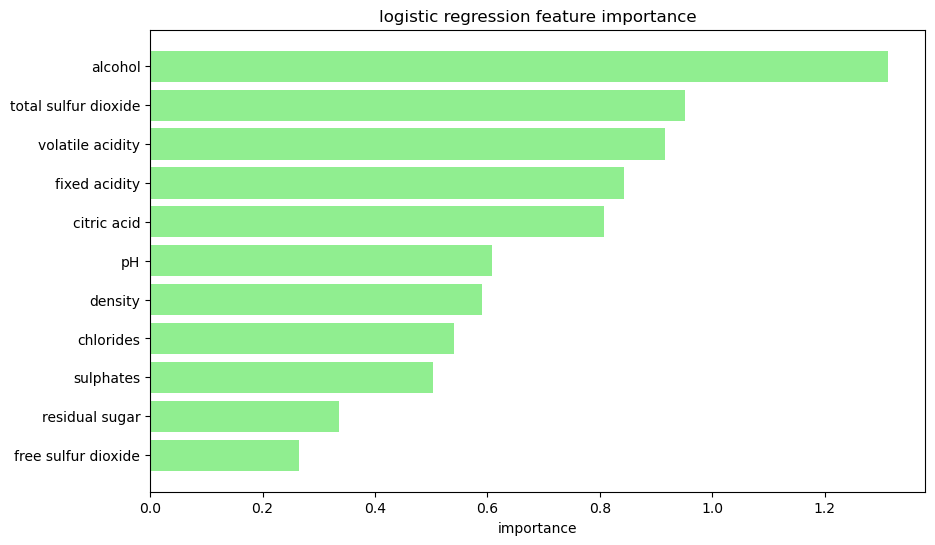

In [9]:
'''
featuring importance: find which features has the most influence on quality determination
'''
coefficient = logistic_regression.coef_
importance = np.mean(np.abs(coefficient),axis=0)
features = X_train.columns
indices = np.argsort(importance)
plt.figure(figsize=(10,6))
plt.barh(features[indices],importance[indices],color='lightgreen')
plt.xlabel("importance")
plt.title("logistic regression feature importance")
plt.show()

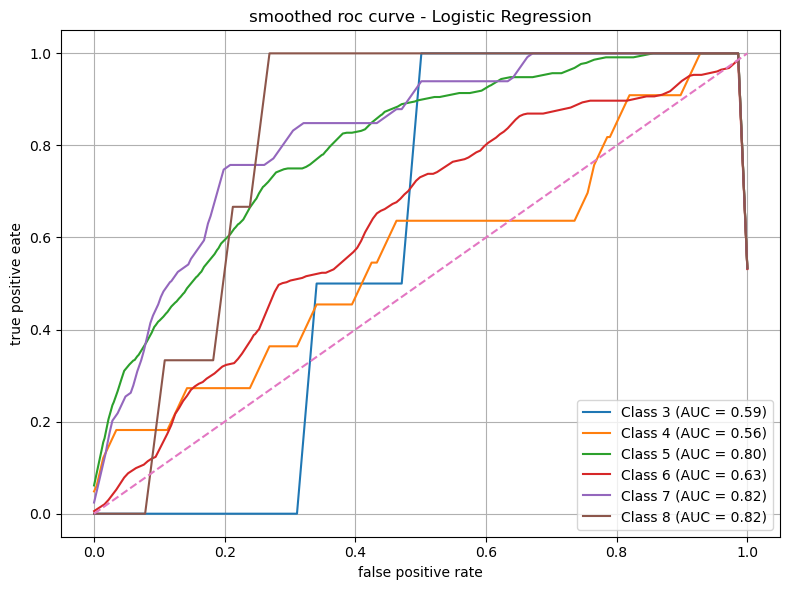

roc_auc: 0.7233593020901727


In [11]:
'''
ROC AUC
'''
#imports needed
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
# probabilities from trained model
y_pred_proba = logistic_regression.predict_proba(scaled_X_test)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )
    # high res interpolation
    fpr_dense = np.linspace(0, 1, 500)
    tpr_interp = np.interp(fpr_dense, fpr, tpr)
    # use averages
    window = 15
    kernel = np.ones(window) / window
    tpr_smooth = np.convolve(tpr_interp, kernel, mode='same')
    roc_auc_class = auc(fpr, tpr)
    plt.plot(
        fpr_dense,
        tpr_smooth,
        label=f"Class {classes[i]} (AUC = {roc_auc_class:.2f})"
    )

# baseline
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("false positive rate")
plt.ylabel("true positive eate")
plt.title("smoothed roc curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# computing
roc_auc = roc_auc_score(y_test_bin, y_pred_proba, average="weighted", multi_class="ovr")
print("roc_auc:", roc_auc)
